In [12]:
## download the data
import pandas as pd

train_df = pd.read_csv("data/2008_2018.csv")
test_df = pd.read_csv("data/2019.csv")
print(train_df.shape)
print(train_df.columns)
train_df.head()

(1646, 21)
Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2018,12,UA,United Air Lines Network,RDU,"Raleigh/Durham, NC: Raleigh-Durham International",483.0,88.0,29.25,2.96,...,0.00,37.12,2.0,0.0,5483.0,1456.0,352.0,1021.0,0.0,2654.0
1,2018,12,WN,Southwest Airlines,RDU,"Raleigh/Durham, NC: Raleigh-Durham International",1020.0,232.0,95.81,3.12,...,3.39,93.86,43.0,3.0,11298.0,4233.0,184.0,1583.0,361.0,4937.0
2,2018,12,YV,Mesa Airlines Inc.,RDU,"Raleigh/Durham, NC: Raleigh-Durham International",40.0,2.0,1.00,0.00,...,0.00,0.00,3.0,0.0,45.0,27.0,0.0,18.0,0.0,0.0
3,2018,12,YX,Republic Airline,RDU,"Raleigh/Durham, NC: Raleigh-Durham International",594.0,99.0,25.71,5.00,...,0.00,27.00,23.0,0.0,5184.0,1315.0,180.0,1432.0,0.0,2257.0
4,2018,12,9E,Endeavor Air Inc.,RDU,"Raleigh/Durham, NC: Raleigh-Durham International",404.0,67.0,13.92,1.26,...,0.00,39.19,18.0,2.0,5981.0,1179.0,707.0,497.0,0.0,3598.0


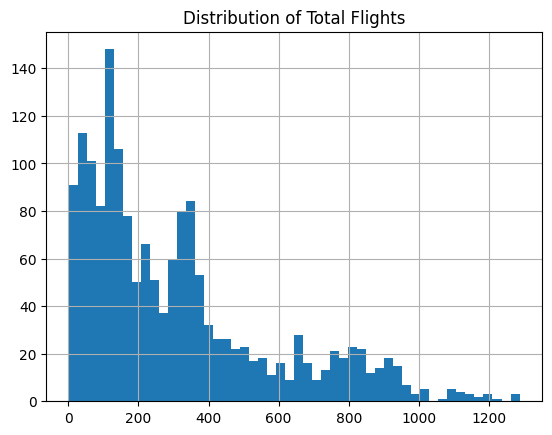

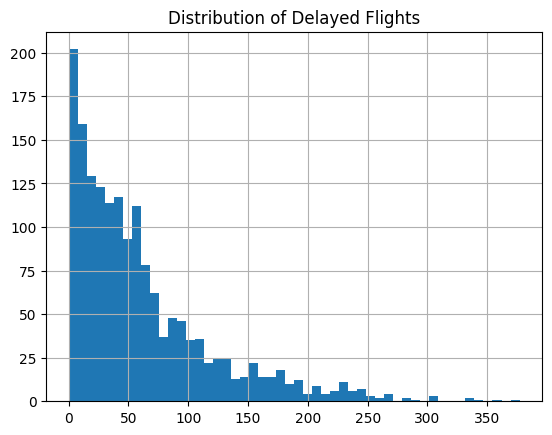

In [13]:
import matplotlib.pyplot as plt

train_df["arr_flights"].hist(bins=50)
plt.title("Distribution of Total Flights")
plt.show()

train_df["arr_del15"].hist(bins=50)
plt.title("Distribution of Delayed Flights")
plt.show()

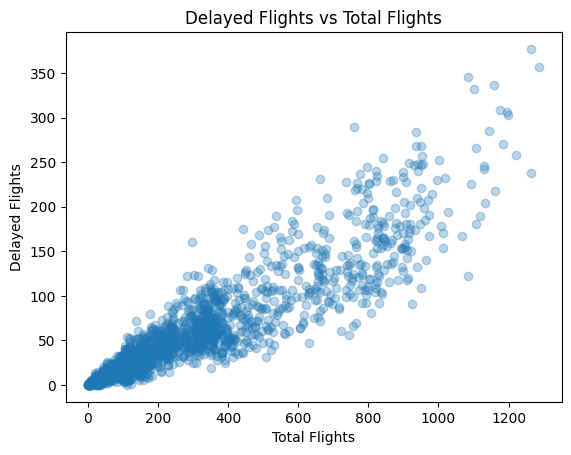

In [14]:
plt.scatter(train_df["arr_flights"], train_df["arr_del15"], alpha=0.3)
plt.xlabel("Total Flights")
plt.ylabel("Delayed Flights")
plt.title("Delayed Flights vs Total Flights")
plt.show()

In [15]:
## check missing values
train_df.isnull().sum().sort_values(ascending=False)

year                   0
security_ct            0
security_delay         0
nas_delay              0
weather_delay          0
carrier_delay          0
arr_delay              0
arr_diverted           0
arr_cancelled          0
late_aircraft_ct       0
nas_ct                 0
month                  0
weather_ct             0
carrier_ct             0
arr_del15              0
arr_flights            0
airport_name           0
airport                0
carrier_name           0
carrier                0
late_aircraft_delay    0
dtype: int64

In [16]:
test_df.isnull().sum().sort_values(ascending=False)

year                   0
security_ct            0
security_delay         0
nas_delay              0
weather_delay          0
carrier_delay          0
arr_delay              0
arr_diverted           0
arr_cancelled          0
late_aircraft_ct       0
nas_ct                 0
month                  0
weather_ct             0
carrier_ct             0
arr_del15              0
arr_flights            0
airport_name           0
airport                0
carrier_name           0
carrier                0
late_aircraft_delay    0
dtype: int64

In [17]:
## Check data types
train_df.dtypes

year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
dtype: object

In [18]:
## check some key columns
train_df[["arr_flights", "arr_del15"]].describe()

,arr_flights,arr_del15
count,1646.000000,1646.000000
mean,309.088700,61.057108
std,269.371353,59.257445
min,1.000000,0.000000
25%,108.000000,18.000000
50%,228.500000,43.500000
75%,413.000000,83.000000
max,1287.000000,377.000000


In [19]:
# remove zero flights
train_df = train_df[train_df["arr_flights"] > 0]

# aggregate to monthly level
monthly_train = (
    train_df.groupby(["year", "month"])
    .agg({"arr_flights": "sum", "arr_del15": "sum"})
    .reset_index()
)

# create delay_rate
monthly_train["delay_rate"] = monthly_train["arr_del15"] / monthly_train["arr_flights"]

# create datetime index
monthly_train["date"] = pd.to_datetime(monthly_train[["year", "month"]].assign(day=1))
monthly_train = monthly_train.set_index("date")

monthly_train["delay_rate"]

date
2008-01-01    0.211101
2008-02-01    0.262036
2008-03-01    0.258312
2008-04-01    0.231511
2008-05-01    0.181113
                ...   
2018-08-01    0.258509
2018-09-01    0.181372
2018-10-01    0.162430
2018-11-01    0.209721
2018-12-01    0.194920
Name: delay_rate, Length: 132, dtype: float64

In [20]:
## modeling dataset
ts_df = monthly_train[["delay_rate"]].copy()
ts_df.head()

,delay_rate
date,
2008-01-01,0.211101
2008-02-01,0.262036
2008-03-01,0.258312
2008-04-01,0.231511
2008-05-01,0.181113


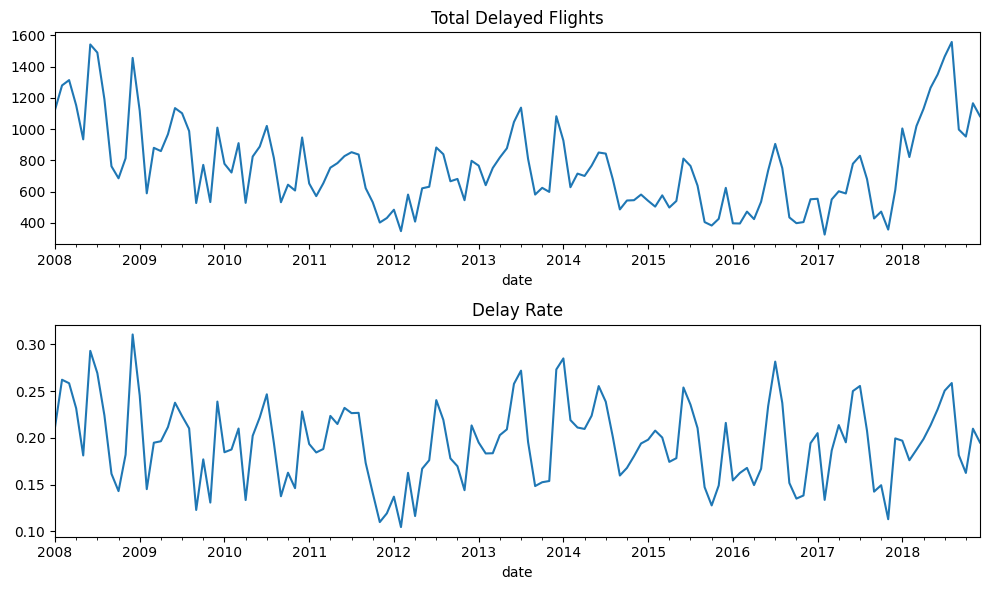

In [21]:
# Compare total delayed flights and delay rate over time
monthly_eda = (
    train_df.groupby(["year", "month"])
    .agg({"arr_flights": "sum", "arr_del15": "sum"})
    .reset_index()
)

monthly_eda["delay_rate"] = monthly_eda["arr_del15"] / monthly_eda["arr_flights"]

monthly_eda["date"] = pd.to_datetime(monthly_eda[["year", "month"]].assign(day=1))
monthly_eda = monthly_eda.set_index("date")

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

monthly_eda["arr_del15"].plot(ax=ax[0], title="Total Delayed Flights")
monthly_eda["delay_rate"].plot(ax=ax[1], title="Delay Rate")

plt.tight_layout()
plt.show()

In [22]:
## Preprocessing the test set (2019)
test_df = test_df[test_df["arr_flights"] > 0]

# aggregate to monthly level
monthly_test = (
    test_df.groupby(["year", "month"])
    .agg({"arr_flights": "sum", "arr_del15": "sum"})
    .reset_index()
)

# create delay_rate
monthly_test["delay_rate"] = monthly_test["arr_del15"] / monthly_test["arr_flights"]

# create datetime index
monthly_test["date"] = pd.to_datetime(monthly_test[["year", "month"]].assign(day=1))
monthly_test = monthly_test.set_index("date")

# modeling series
ts_test = monthly_test[["delay_rate"]]

ts_test.head()

,delay_rate
date,
2019-01-01,0.195810
2019-02-01,0.213677
2019-03-01,0.172546
2019-04-01,0.194942
2019-05-01,0.214856


In [23]:
monthly_train.to_csv("data/clean_train_monthly.csv", index=False)
monthly_test.to_csv("data/clean_test_monthly.csv", index=False)